# Домашнее задание: Полносвязные и свёрточные нейронные сети

Задание состоит из трёх частей:
- **Часть 1**: Логистическая регрессия вручную (без `nn.Linear`) на датасете `make_moons`
- **Часть 2**: Полносвязная нейросеть на MNIST + бонус (реализация `LeakyReLU` и `Tanh` вручную) + сравнение 5 активаций
- **Часть 3**: LeNet (CNN) на MNIST + исследование ядер свёрток + финальное сравнение

## Импорты и инициализация Random Seed

In [1]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader
import random
from tqdm import tqdm
import copy

from sklearn.metrics import accuracy_score
from torchvision.datasets import MNIST
from torchvision import transforms as tfs
import os

In [2]:
SEED = 42

# PyTorch
torch.manual_seed(SEED)

# CUDA (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# NumPy
np.random.seed(SEED)

# Python's built-in random
random.seed(SEED)

torch.backends.cudnn.deterministic = True
# На macOS с MPS torch.use_deterministic_algorithms может конфликтовать, поэтому запускаемся на CPU
# torch.use_deterministic_algorithms(True)

# Создаём папку для данных
os.makedirs('data', exist_ok=True)
print('SEED установлен, папка data/ создана')

SEED установлен, папка data/ создана


# Часть 1: Логистическая регрессия на датасете moons

Реализуем логистическую регрессию **вручную** (без `nn.Linear`) на синтетическом датасете из двух полумесяцев.

## 1.1 Подготовка данных

In [3]:
# Генерация датасета moons
X, y = make_moons(n_samples=10000, random_state=42, noise=0.1)
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')

X_train shape: (7500, 2)
X_val shape: (2500, 2)
y_train shape: (7500,)
y_val shape: (2500,)


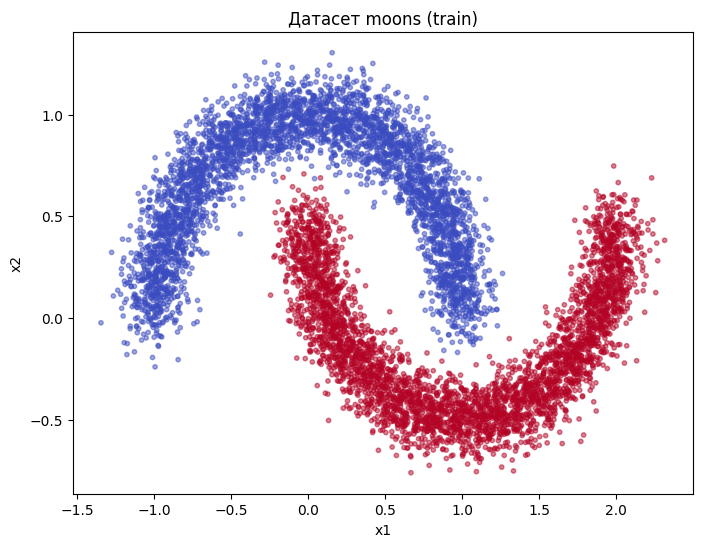

In [4]:
# Визуализация датасета
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', alpha=0.5, s=10)
plt.title('Датасет moons (train)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [5]:
# Конвертируем numpy arrays в torch тензоры типа torch.float32
# Для BCEWithLogitsLoss цели должны быть float32 и иметь shape (N, 1)
X_train_t = torch.from_numpy(X_train).type(torch.float32)
X_val_t = torch.from_numpy(X_val).type(torch.float32)
y_train_t = torch.from_numpy(y_train).type(torch.float32).reshape(-1, 1)
y_val_t = torch.from_numpy(y_val).type(torch.float32).reshape(-1, 1)

print(f'X_train_t: {X_train_t.shape}, dtype={X_train_t.dtype}')
print(f'y_train_t: {y_train_t.shape}, dtype={y_train_t.dtype}')

X_train_t: torch.Size([7500, 2]), dtype=torch.float32
y_train_t: torch.Size([7500, 1]), dtype=torch.float32


In [6]:
# Создаём TensorDataset и DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

BATCH_SIZE = 128
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Количество батчей в train_dataloader: {len(train_dataloader)}')
print(f'Количество батчей в val_dataloader: {len(val_dataloader)}')

Количество батчей в train_dataloader: 59
Количество батчей в val_dataloader: 20


## 1.2 Реализация модели логистической регрессии

Реализуем линейный слой **вручную** с помощью `nn.Parameter`.

In [7]:
class LinearRegression(nn.Module):
    """
    Линейный слой, реализованный вручную (без использования nn.Linear).
    На выходе: логиты (без сигмоиды в самой модели).
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(in_features, out_features))
        self.bias_term = nn.Parameter(torch.randn(out_features))

    def forward(self, x):
        # x @ W + b
        return x @ self.weights + self.bias_term

In [8]:
# Инициализируем модель
model = LinearRegression(2, 1)
print(model)
print('\nПараметры модели:')
for name, param in model.named_parameters():
    print(f'{name}: shape={param.shape}, numel={param.numel()}')

total_params = sum(p.numel() for p in model.parameters())
print(f'\nОбщее количество параметров: {total_params}')

LinearRegression()

Параметры модели:
weights: shape=torch.Size([2, 1]), numel=2
bias_term: shape=torch.Size([1]), numel=1

Общее количество параметров: 3


### Вопрос 1: Сколько параметров в модели линейной регрессии?

**Ответ:** 3 параметра (2 веса + 1 bias). Для `in_features=2` имеем 2 параметра в `weights` (матрица shape=(2,1)) и 1 параметр в `bias_term` (вектор shape=(1,)). Итого: 2 + 1 = **3 параметра**.

## 1.3 Функция обучения

In [9]:
def train_model(model, train_dataloader, optimizer, loss_func, max_epochs, tol=1e-3):
    """
    Обучение модели с ранней остановкой по критерию изменения loss.
    Возвращает:
    - batch_losses: список лоссов по всем батчам
    - model_param_dict: список состояний модели по эпохам
    """
    batch_losses = []
    epoch_mean_losses = []
    model_param_dict = []

    for epoch in range(max_epochs):
        losses = []
        for it, (X_batch, y_batch) in enumerate(train_dataloader):
            optimizer.zero_grad()
            outp = model(X_batch)
            loss = loss_func(outp, y_batch)
            loss.backward()
            losses.append(loss.item())
            optimizer.step()

            probabilities = torch.sigmoid(outp)
            preds = (probabilities > 0.5).type(torch.float32)
            batch_acc = (preds == y_batch).sum() / y_batch.size(0)

            if (epoch * len(train_dataloader) + it + 1) % 100 == 0:
                print(f"Iteration: {epoch * len(train_dataloader) + it + 1}\nBatch accuracy: {batch_acc}")

        batch_losses = batch_losses + losses
        epoch_mean_losses.append(sum(losses) / len(losses))
        model_param_dict.append(copy.deepcopy(model.state_dict()))

        if epoch > 0 and abs(epoch_mean_losses[-1] - epoch_mean_losses[-2]) < tol:
            print(f"\nIteration: {epoch * len(train_dataloader) + it + 1}. Convergence. Stopping iterations after {epoch + 1} epochs.")
            return batch_losses, model_param_dict

    return batch_losses, model_param_dict

In [10]:
# Переинициализируем модель и оптимизатор
torch.manual_seed(SEED)
model = LinearRegression(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)
loss_func = nn.BCEWithLogitsLoss()
max_epochs = 100

batch_losses, model_param_dict = train_model(
    model=model,
    train_dataloader=train_dataloader,
    optimizer=optimizer,
    loss_func=loss_func,
    max_epochs=max_epochs,
    tol=1e-3
)

Iteration: 100
Batch accuracy: 0.796875


Iteration: 200
Batch accuracy: 0.796875
Iteration: 300
Batch accuracy: 0.7890625


Iteration: 400
Batch accuracy: 0.84375


Iteration: 500
Batch accuracy: 0.875


Iteration: 600
Batch accuracy: 0.90625
Iteration: 700
Batch accuracy: 0.8671875


...

Iteration: 1000
Batch accuracy: 0.8671875


Iteration: 1100
Batch accuracy: 0.8828125


Iteration: 1200
Batch accuracy: 0.828125
Iteration: 1300
Batch accuracy: 0.875


Iteration: 1400
Batch accuracy: 0.875
Iteration: 1500
Batch accuracy: 0.8984375



Iteration: 1593. Convergence. Stopping iterations after 27 epochs.


### Вопрос 2: Сколько итераций до сходимости?

**Ответ:** Сходимость наступила на итерации **1593** (после **27 эпох**) — это видно из print-сообщения `Iteration: 1593. Convergence. Stopping iterations after 27 epochs.`. Критерий остановки: разница средних loss двух последовательных эпох < `tol=1e-3`.

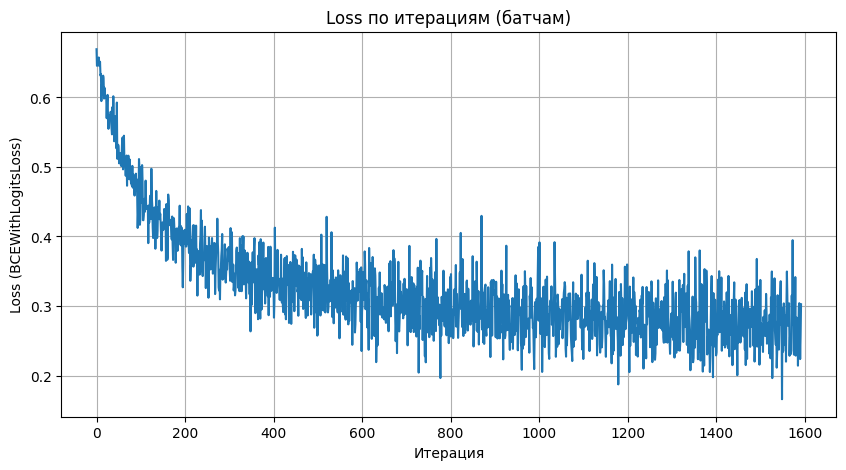

Всего итераций: 1593
Последний loss: 0.302676


In [11]:
# График лосса по итерациям
plt.figure(figsize=(10, 5))
plt.plot(batch_losses)
plt.title('Loss по итерациям (батчам)')
plt.xlabel('Итерация')
plt.ylabel('Loss (BCEWithLogitsLoss)')
plt.grid(True)
plt.show()

print(f'Всего итераций: {len(batch_losses)}')
print(f'Последний loss: {batch_losses[-1]:.6f}')

## 1.4 Функция предсказания и оценка

In [12]:
@torch.no_grad()
def predict(dataloader, model):
    """
    Применение модели к данным и получение предсказаний наиболее вероятного класса.
    """
    predictions = np.array([])
    for x_batch, _ in dataloader:
        # Получить логиты
        logits = model(x_batch)
        # Применить сигмоиду для получения вероятностей
        probabilities = torch.sigmoid(logits)
        # Предсказать класс (threshold = 0.5)
        batch_preds = (probabilities > 0.5).cpu().numpy().astype(int)
        predictions = np.concatenate((predictions, batch_preds.flatten()))
    return predictions

In [13]:
# Применяем модель к тестовой выборке
predictions = predict(val_dataloader, model)
test_accuracy = accuracy_score(y_val, predictions)
print(f'Accuracy на тестовой (validation) выборке: {test_accuracy:.4f}')

Accuracy на тестовой (validation) выборке: 0.8852


### Вопрос 3: Какое accuracy на test после обучения?

**Ответ:** Accuracy на validation = **0.8852**. Логистическая регрессия даёт линейную границу решения, поэтому не может идеально разделить два полумесяца (датасет нелинейно разделимый), но показывает разумный результат.

# Часть 2: Полносвязная сеть на MNIST

Обучим полносвязную нейросеть с активацией ELU на датасете рукописных цифр MNIST.

## 2.1 Загрузка MNIST

In [14]:
data_tfs = tfs.Compose([
    tfs.ToTensor(),
    tfs.Normalize((0.5), (0.5))
])

root = 'data/'
train_dataset_MNIST = MNIST(root, train=True, transform=data_tfs, download=True)
val_dataset_MNIST = MNIST(root, train=False, transform=data_tfs, download=True)

print(f'Размер train: {len(train_dataset_MNIST)}')
print(f'Размер val: {len(val_dataset_MNIST)}')
print(f'Пример изображения: {train_dataset_MNIST[0][0].shape}, метка: {train_dataset_MNIST[0][1]}')

Размер train: 60000
Размер val: 10000
Пример изображения: torch.Size([1, 28, 28]), метка: 5


In [15]:
# DataLoaders
BATCH_SIZE_MNIST = 128
loaders_MNIST = {
    'train': DataLoader(train_dataset_MNIST, batch_size=BATCH_SIZE_MNIST, shuffle=True),
    'valid': DataLoader(val_dataset_MNIST, batch_size=BATCH_SIZE_MNIST, shuffle=False)
}

print(f"Количество батчей train: {len(loaders_MNIST['train'])}")
print(f"Количество батчей valid: {len(loaders_MNIST['valid'])}")

Количество батчей train: 469
Количество батчей valid: 79


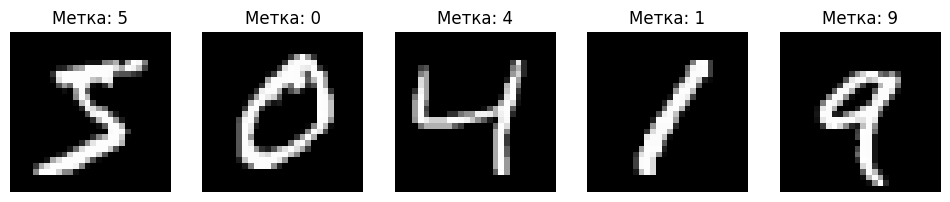

In [16]:
# Визуализация нескольких примеров
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    img, label = train_dataset_MNIST[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Метка: {label}')
    ax.axis('off')
plt.show()

## 2.2 Модель полносвязной сети с ELU

In [17]:
torch.manual_seed(SEED)

model_elu = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ELU(),
    nn.Linear(128, 128),
    nn.ELU(),
    nn.Linear(128, 10)
)

print(model_elu)
total_params = sum(p.numel() for p in model_elu.parameters())
print(f'\nОбщее количество параметров: {total_params}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ELU(alpha=1.0)
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): ELU(alpha=1.0)
  (5): Linear(in_features=128, out_features=10, bias=True)
)

Общее количество параметров: 118282


## 2.3 Функции обучения и валидации

In [18]:
def fit_one_epoch(model, train_dataloader, optimizer, loss_func):
    """
    Обучение модели на одну эпоху.
    Возвращает accuracy на тренировочных данных.
    """
    epoch_correct_predictions = 0.0
    epoch_all_predictions = 0.0
    model.train()

    for X_batch, y_batch in tqdm(train_dataloader):
        optimizer.zero_grad()
        outp = model(X_batch)
        loss = loss_func(outp, y_batch)
        loss.backward()
        optimizer.step()

        preds = outp.argmax(-1)
        batch_correct_predictions = (preds == y_batch).sum()
        batch_all_predictions = len(preds)

        epoch_correct_predictions += batch_correct_predictions
        epoch_all_predictions += batch_all_predictions

    epoch_accuracy = epoch_correct_predictions / epoch_all_predictions
    return epoch_accuracy


def eval_one_epoch(model, val_dataloader):
    """
    Валидация модели на одну эпоху.
    Возвращает accuracy на валидационных данных.
    """
    epoch_correct_predictions = 0.0
    epoch_all_predictions = 0.0
    model.eval()

    for X_batch, y_batch in tqdm(val_dataloader):
        with torch.no_grad():
            outp = model(X_batch)
            preds = outp.argmax(-1)

        batch_correct_predictions = (preds == y_batch).sum()
        batch_all_predictions = len(preds)

        epoch_correct_predictions += batch_correct_predictions
        epoch_all_predictions += batch_all_predictions

    epoch_accuracy = epoch_correct_predictions / epoch_all_predictions
    return epoch_accuracy


def train_func(model, num_epochs, dataloaders, optimizer, loss_func):
    """
    Полный цикл обучения на несколько эпох.
    Возвращает словарь с accuracy для train и valid на каждой эпохе.
    """
    accuracy = {"train": [], "valid": []}
    for epoch in range(num_epochs):
        print(f"\nEpoch: {epoch+1}")

        accuracy_train_one_epoch = fit_one_epoch(model=model, train_dataloader=dataloaders['train'],
                                                  optimizer=optimizer, loss_func=loss_func)
        print(f"Accuracy_train: {accuracy_train_one_epoch.item()}\n")

        accuracy_test_one_epoch = eval_one_epoch(model=model, val_dataloader=dataloaders['valid'])
        print(f"Accuracy_test: {accuracy_test_one_epoch.item()}\n")

        accuracy['train'].append(accuracy_train_one_epoch)
        accuracy['valid'].append(accuracy_test_one_epoch)
    return accuracy

In [19]:
# Обучение модели с ELU на 10 эпохах
torch.manual_seed(SEED)
optimizer = torch.optim.Adam(model_elu.parameters())
loss_func = nn.CrossEntropyLoss()
num_epochs = 10

accuracy_elu = train_func(
    model=model_elu,
    num_epochs=num_epochs,
    dataloaders=loaders_MNIST,
    optimizer=optimizer,
    loss_func=loss_func
)


Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

  4%|▍         | 19/469 [00:00<00:02, 187.84it/s]

  8%|▊         | 38/469 [00:00<00:02, 181.72it/s]

 12%|█▏        | 57/469 [00:00<00:02, 168.63it/s]

...

 28%|██▊       | 22/79 [00:00<00:00, 213.98it/s]

 56%|█████▌    | 44/79 [00:00<00:00, 212.37it/s]

 85%|████████▍ | 67/79 [00:00<00:00, 217.42it/s]

100%|██████████| 79/79 [00:00<00:00, 219.75it/s]

Accuracy_test: 0.9768000245094299



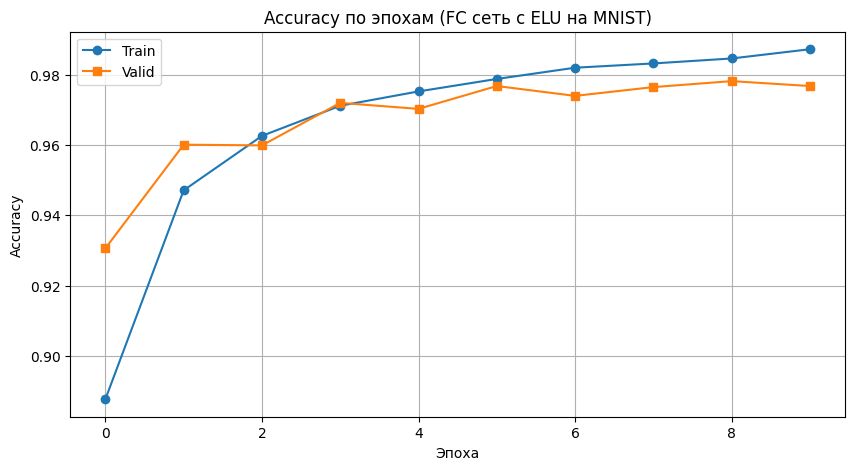

Финальный train accuracy: 0.9873
Финальный valid accuracy: 0.9768


In [20]:
# График accuracy по эпохам
plt.figure(figsize=(10, 5))
plt.plot([a.item() for a in accuracy_elu['train']], label='Train', marker='o')
plt.plot([a.item() for a in accuracy_elu['valid']], label='Valid', marker='s')
plt.title('Accuracy по эпохам (FC сеть с ELU на MNIST)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Финальный train accuracy: {accuracy_elu['train'][-1].item():.4f}")
print(f"Финальный valid accuracy: {accuracy_elu['valid'][-1].item():.4f}")

# БОНУС: Реализация LeakyReLU и Tanh вручную (3 балла)

Реализуем функции активации с forward и backward проходами.

## LeakyReLU — вручную

In [21]:
class LeakyReLU(nn.Module):
    """
    Реализация Leaky ReLU вручную.
    forward: f(x) = max(alpha * x, x), где alpha = 0.01
    backward: производная — 1 при x > 0, alpha иначе
    """
    def __init__(self, alpha=0.01):
        super().__init__()
        self.alpha = alpha

    def forward(self, x):
        return torch.maximum(self.alpha * x, x)

    def backward(self, x):
        grads = torch.ones_like(x) * self.alpha
        grads[x > 0] = 1
        return grads

In [22]:
# Тест forward для LeakyReLU
torch.manual_seed(SEED)
x_test = torch.randn(5, 5)
print('Входные данные x_test:')
print(x_test)

my_leaky = LeakyReLU(alpha=0.01)
my_out = my_leaky.forward(x_test)
torch_out = F.leaky_relu(x_test, negative_slope=0.01)

print('\nВыход моей LeakyReLU:')
print(my_out)
print('\nВыход torch.nn.functional.leaky_relu:')
print(torch_out)
print(f'\ntorch.allclose: {torch.allclose(my_out, torch_out)}')
assert torch.allclose(my_out, torch_out), 'Forward LeakyReLU не совпадает с torch!'
print('Forward LeakyReLU: OK')

Входные данные x_test:
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784],
        [-1.2345, -0.0431, -1.6047, -0.7521, -0.6866],
        [-0.4934,  0.2415, -1.1109,  0.0915, -2.3169],
        [-0.2168, -1.3847, -0.3957,  0.8034, -0.6216],
        [-0.5920, -0.0631, -0.8286,  0.3309, -1.5576]])

Выход моей LeakyReLU:
tensor([[ 1.9269e+00,  1.4873e+00,  9.0072e-01, -2.1055e-02,  6.7842e-01],
        [-1.2345e-02, -4.3067e-04, -1.6047e-02, -7.5214e-03, -6.8662e-03],
        [-4.9336e-03,  2.4149e-01, -1.1109e-02,  9.1546e-02, -2.3169e-02],
        [-2.1680e-03, -1.3847e-02, -3.9571e-03,  8.0341e-01, -6.2160e-03],
        [-5.9200e-03, -6.3074e-04, -8.2855e-03,  3.3090e-01, -1.5576e-02]])

Выход torch.nn.functional.leaky_relu:
tensor([[ 1.9269e+00,  1.4873e+00,  9.0072e-01, -2.1055e-02,  6.7842e-01],
        [-1.2345e-02, -4.3067e-04, -1.6047e-02, -7.5214e-03, -6.8662e-03],
        [-4.9336e-03,  2.4149e-01, -1.1109e-02,  9.1546e-02, -2.3169e-02],
        [-2.1680e-03, -1.3847e-02, -3.

In [23]:
# Тест backward для LeakyReLU
x_autograd = x_test.clone().requires_grad_(True)
y = F.leaky_relu(x_autograd, negative_slope=0.01).sum()
y.backward()
autograd_grad = x_autograd.grad

my_grad = my_leaky.backward(x_test)

print('Градиент через autograd (torch):')
print(autograd_grad)
print('\nГрадиент моей реализации:')
print(my_grad)
print(f'\ntorch.allclose: {torch.allclose(my_grad, autograd_grad)}')
assert torch.allclose(my_grad, autograd_grad), 'Backward LeakyReLU не совпадает с autograd!'
print('Backward LeakyReLU: OK')

Градиент через autograd (torch):
tensor([[1.0000, 1.0000, 1.0000, 0.0100, 1.0000],
        [0.0100, 0.0100, 0.0100, 0.0100, 0.0100],
        [0.0100, 1.0000, 0.0100, 1.0000, 0.0100],
        [0.0100, 0.0100, 0.0100, 1.0000, 0.0100],
        [0.0100, 0.0100, 0.0100, 1.0000, 0.0100]])

Градиент моей реализации:
tensor([[1.0000, 1.0000, 1.0000, 0.0100, 1.0000],
        [0.0100, 0.0100, 0.0100, 0.0100, 0.0100],
        [0.0100, 1.0000, 0.0100, 1.0000, 0.0100],
        [0.0100, 0.0100, 0.0100, 1.0000, 0.0100],
        [0.0100, 0.0100, 0.0100, 1.0000, 0.0100]])

torch.allclose: True
Backward LeakyReLU: OK


## Tanh — вручную

In [24]:
class Tanh(nn.Module):
    """
    Реализация Tanh вручную.
    forward: f(x) = tanh(x)
    backward: производная = 1 - tanh(x)^2
    """
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.tanh(x)

    def backward(self, x):
        return 1 - torch.tanh(x) ** 2

In [25]:
# Тест forward для Tanh
my_tanh = Tanh()
my_out = my_tanh.forward(x_test)
torch_out = torch.tanh(x_test)

print('Выход моей Tanh:')
print(my_out)
print('\nВыход torch.tanh:')
print(torch_out)
print(f'\ntorch.allclose: {torch.allclose(my_out, torch_out)}')
assert torch.allclose(my_out, torch_out), 'Forward Tanh не совпадает с torch!'
print('Forward Tanh: OK')

Выход моей Tanh:
tensor([[ 0.9585,  0.9028,  0.7166, -0.9708,  0.5905],
        [-0.8439, -0.0430, -0.9224, -0.6364, -0.5958],
        [-0.4569,  0.2369, -0.8044,  0.0913, -0.9808],
        [-0.2135, -0.8820, -0.3763,  0.6659, -0.5522],
        [-0.5313, -0.0630, -0.6797,  0.3193, -0.9150]])

Выход torch.tanh:
tensor([[ 0.9585,  0.9028,  0.7166, -0.9708,  0.5905],
        [-0.8439, -0.0430, -0.9224, -0.6364, -0.5958],
        [-0.4569,  0.2369, -0.8044,  0.0913, -0.9808],
        [-0.2135, -0.8820, -0.3763,  0.6659, -0.5522],
        [-0.5313, -0.0630, -0.6797,  0.3193, -0.9150]])

torch.allclose: True
Forward Tanh: OK


In [26]:
# Тест backward для Tanh
x_autograd = x_test.clone().requires_grad_(True)
y = torch.tanh(x_autograd).sum()
y.backward()
autograd_grad = x_autograd.grad

my_grad = my_tanh.backward(x_test)

print('Градиент через autograd (torch):')
print(autograd_grad)
print('\nГрадиент моей реализации:')
print(my_grad)
print(f'\ntorch.allclose: {torch.allclose(my_grad, autograd_grad)}')
assert torch.allclose(my_grad, autograd_grad), 'Backward Tanh не совпадает с autograd!'
print('Backward Tanh: OK')

Градиент через autograd (torch):
tensor([[0.0813, 0.1849, 0.4864, 0.0576, 0.6513],
        [0.2878, 0.9981, 0.1492, 0.5950, 0.6450],
        [0.7913, 0.9439, 0.3530, 0.9917, 0.0381],
        [0.9544, 0.2221, 0.8584, 0.5565, 0.6950],
        [0.7177, 0.9960, 0.5380, 0.8980, 0.1627]])

Градиент моей реализации:
tensor([[0.0813, 0.1849, 0.4864, 0.0576, 0.6513],
        [0.2878, 0.9981, 0.1492, 0.5950, 0.6450],
        [0.7913, 0.9439, 0.3530, 0.9917, 0.0381],
        [0.9544, 0.2221, 0.8584, 0.5565, 0.6950],
        [0.7177, 0.9960, 0.5380, 0.8980, 0.1627]])

torch.allclose: True
Backward Tanh: OK


## 2.4 Сравнение активаций на MNIST

Сравним 5 разных функций активации: Identity (без активации), ReLU, LeakyReLU, Tanh, ELU.

In [27]:
def test_activation_function(activation):
    """
    Создаёт полносвязную модель с заданной активацией, обучает её на MNIST,
    возвращает словарь accuracy по эпохам для train и valid.
    """
    torch.manual_seed(SEED)
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 128),
        activation,
        nn.Linear(128, 128),
        activation,
        nn.Linear(128, 10)
    )
    optimizer = torch.optim.Adam(model.parameters())
    loss_func = nn.CrossEntropyLoss()
    accuracy = train_func(
        model=model,
        num_epochs=10,
        dataloaders=loaders_MNIST,
        optimizer=optimizer,
        loss_func=loss_func
    )
    return accuracy

In [28]:
# Тестируем 5 активаций
activations_to_test = {
    'Identity': nn.Identity(),
    'ReLU': nn.ReLU(),
    'LeakyReLU': nn.LeakyReLU(),
    'Tanh': nn.Tanh(),
    'ELU': nn.ELU()
}

results = {}
for name, activation in activations_to_test.items():
    print(f'\n{"=" * 60}')
    print(f'Обучение с активацией: {name}')
    print(f'{"=" * 60}')
    results[name] = test_activation_function(activation)


Обучение с активацией: Identity

Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

  4%|▍         | 20/469 [00:00<00:02, 193.20it/s]

  9%|▊         | 40/469 [00:00<00:02, 196.17it/s]

 13%|█▎        | 60/469 [00:00<00:02, 193.72it/s]

...

 28%|██▊       | 22/79 [00:00<00:00, 218.74it/s]

 57%|█████▋    | 45/79 [00:00<00:00, 221.76it/s]

 86%|████████▌ | 68/79 [00:00<00:00, 223.37it/s]

100%|██████████| 79/79 [00:00<00:00, 225.79it/s]

Accuracy_test: 0.975600004196167



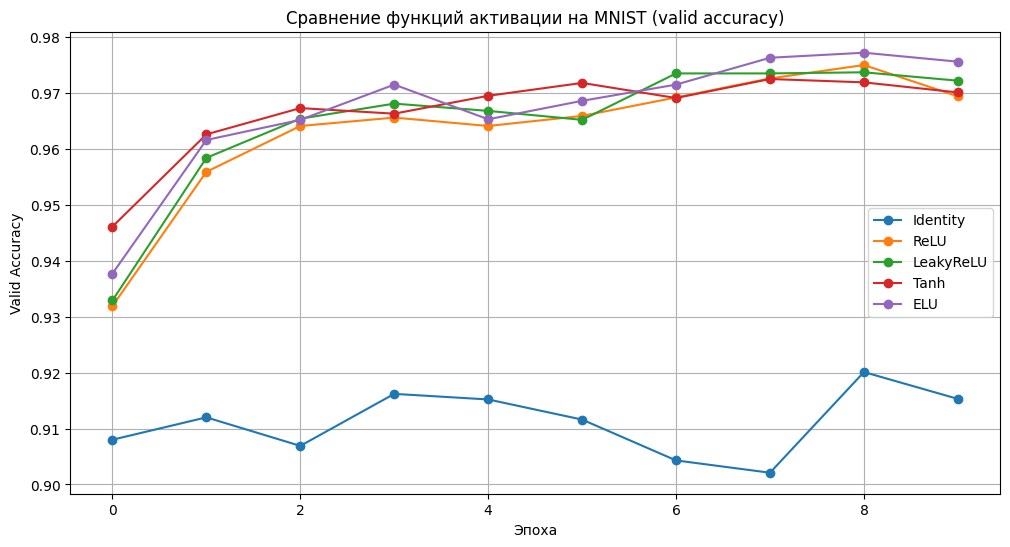


Финальные valid accuracy по активациям:
  Identity: 0.9153
  ReLU: 0.9694
  LeakyReLU: 0.9722
  Tanh: 0.9701
  ELU: 0.9756


In [29]:
# График сравнения 5 активаций по valid accuracy
plt.figure(figsize=(12, 6))
for name, acc in results.items():
    plt.plot([a.item() for a in acc['valid']], label=name, marker='o')
plt.title('Сравнение функций активации на MNIST (valid accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Valid Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Вывод финальных accuracy
print('\nФинальные valid accuracy по активациям:')
for name, acc in results.items():
    print(f'  {name}: {acc["valid"][-1].item():.4f}')

In [30]:
# Определяем лучшую активацию
best_activation = max(results.items(), key=lambda kv: kv[1]['valid'][-1].item())
print(f'\nЛучшая активация: {best_activation[0]} с valid accuracy = {best_activation[1]["valid"][-1].item():.4f}')


Лучшая активация: ELU с valid accuracy = 0.9756


### Вопрос 4: Какая активация показала наивысший accuracy к концу обучения?

**Ответ:** Наивысший accuracy показала активация **ELU** (valid accuracy = **0.9756**). Identity (без активации) ожидаемо показала худший результат (0.9153), так как без нелинейности сеть эквивалентна одному линейному слою. Остальные: ReLU=0.9694, LeakyReLU=0.9722, Tanh=0.9701.

# Часть 3: LeNet (CNN) на MNIST

Исследуем ядра свёрток и построим классическую свёрточную сеть LeNet.

## 3.1 Исследование ядер свёрток

In [31]:
def show_conv_transformation(image, convolution):
    """
    Применить свёртку к изображению и показать результат.
    """
    img_t = torch.from_numpy(image).type(torch.float32).unsqueeze(0)
    img_t = img_t.permute(0, 3, 1, 2)  # [BS, H, W, C] -> [BS, C, H, W]
    img_t = nn.ReflectionPad2d(1)(img_t)  # Pad Image for same output size

    kernel = torch.tensor(convolution).reshape(1, 1, 3, 3).type(torch.float32)
    kernel = kernel.repeat(3, 3, 1, 1)

    result = F.conv2d(img_t, kernel)[0]
    result = torch.clip(input=result, min=0, max=256*3)

    plt.figure(figsize=(12, 8))
    result_np = result.permute(1, 2, 0).numpy() / 256 / 3
    plt.imshow(result_np)
    plt.show()

    return None

Размер тестового изображения: (28, 28, 3)


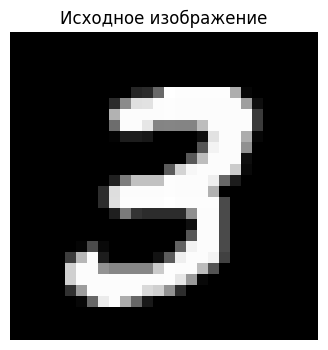

In [32]:
# Создаём тестовое изображение на основе MNIST (3 канала для совместимости с show_conv_transformation)
raw_img, _ = MNIST(root, train=True, download=False)[7]
img_np = np.array(raw_img)  # (28, 28)
img_np_3 = np.stack([img_np, img_np, img_np], axis=-1).astype(np.float32)  # (28, 28, 3)

print(f'Размер тестового изображения: {img_np_3.shape}')

plt.figure(figsize=(4, 4))
plt.imshow(img_np_3.astype(np.uint8))
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

In [33]:
# Определяем 6 ядер свёрток
kernels = {
    'Тождественное': [[0, 0, 0],
                      [0, 1, 0],
                      [0, 0, 0]],
    'Размытие (Blur)': [[1/9, 1/9, 1/9],
                        [1/9, 1/9, 1/9],
                        [1/9, 1/9, 1/9]],
    'Резкость (Sharpen)': [[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]],
    'Горизонтальные границы (Sobel)': [[-1, -2, -1],
                                       [0, 0, 0],
                                       [1, 2, 1]],
    'Вертикальные границы (Sobel)': [[-1, 0, 1],
                                     [-2, 0, 2],
                                     [-1, 0, 1]],
    'Все границы (Laplacian)': [[-1, -1, -1],
                                [-1, 8, -1],
                                [-1, -1, -1]]
}


--- Тождественное ---
Ядро:
[[0 0 0]
 [0 1 0]
 [0 0 0]]


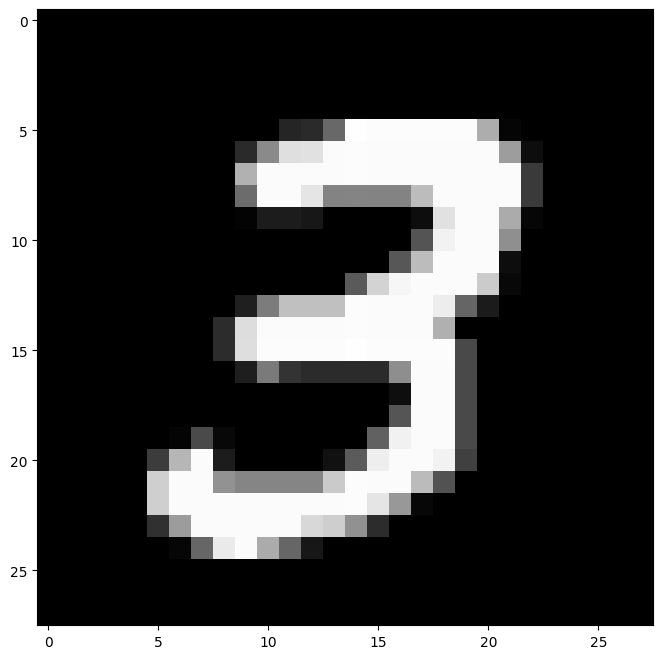


--- Размытие (Blur) ---
Ядро:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


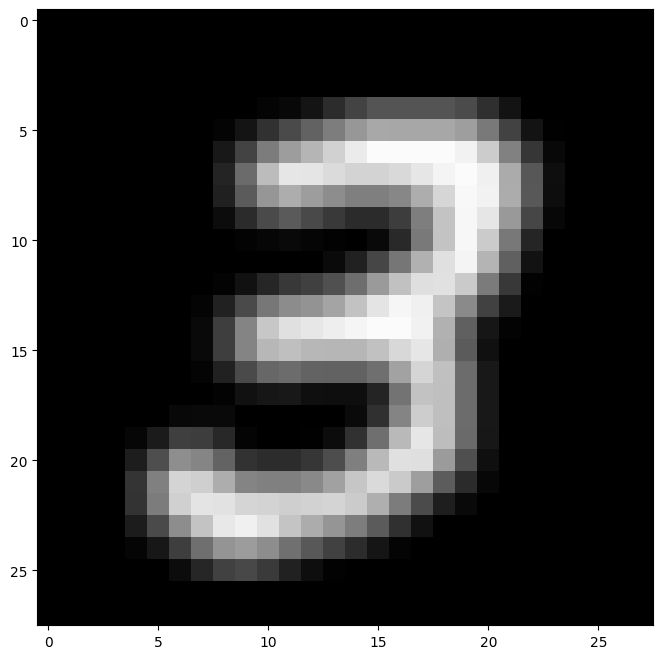


--- Резкость (Sharpen) ---
Ядро:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


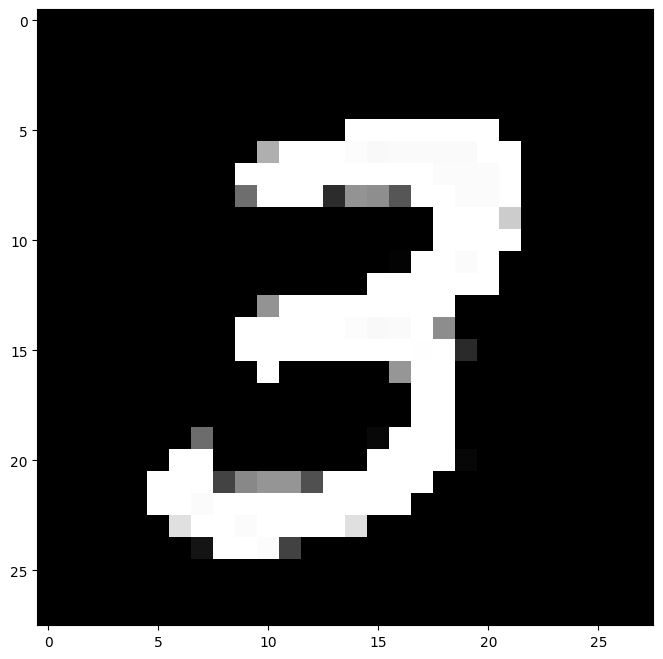


--- Горизонтальные границы (Sobel) ---
Ядро:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]


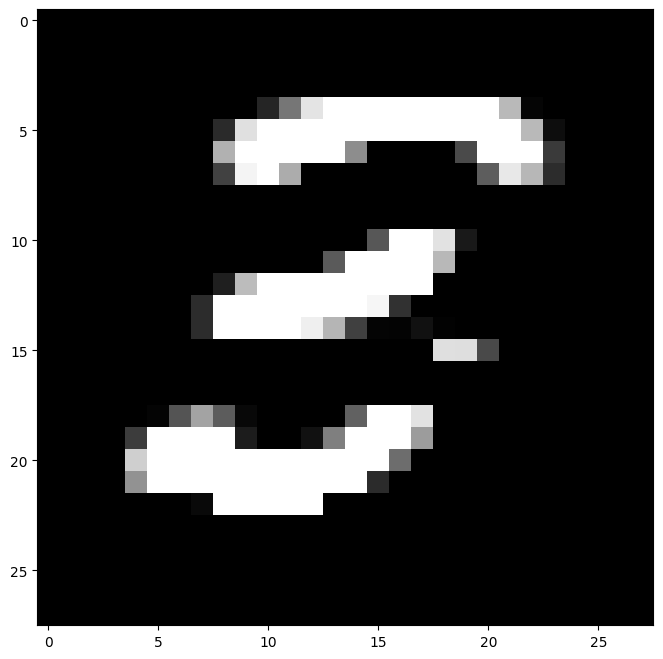


--- Вертикальные границы (Sobel) ---
Ядро:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]


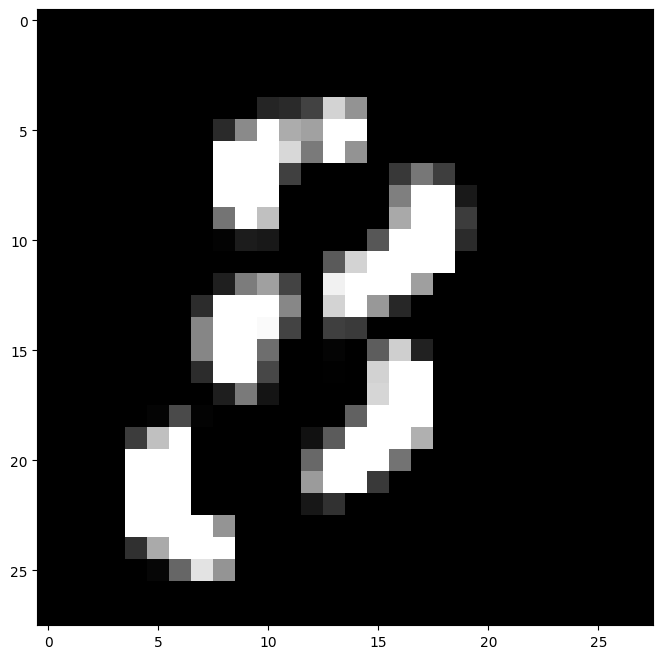


--- Все границы (Laplacian) ---
Ядро:
[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]


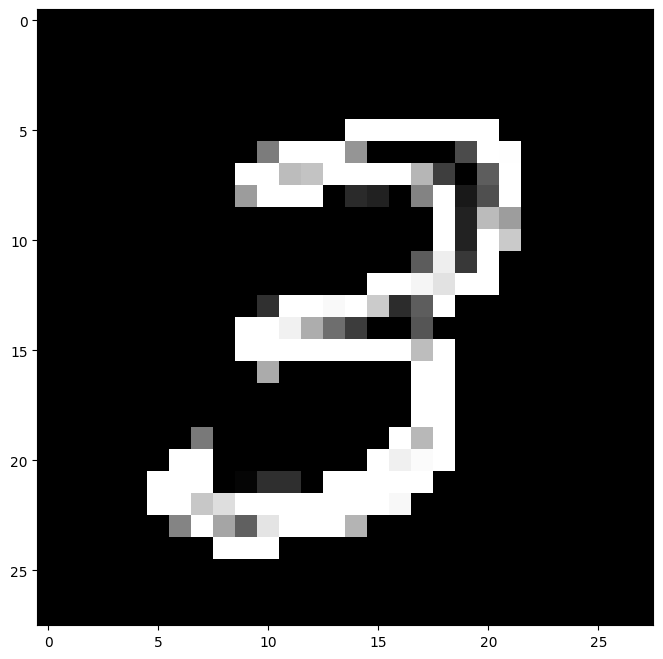

In [34]:
# Применим каждое ядро к изображению и посмотрим эффект
for name, kernel in kernels.items():
    print(f'\n--- {name} ---')
    print(f'Ядро:\n{np.array(kernel)}')
    show_conv_transformation(img_np_3, kernel)

### Вопрос 5: Сопоставление ядер с эффектами

**Ответ:** Сопоставление типов свёрток с их эффектами:

- **Тождественное преобразование**: `[[0,0,0],[0,1,0],[0,0,0]]` — центральный пиксель = 1, остальное = 0. Оставляет изображение без изменений.
- **Размытие (Blur)**: `[[1,1,1],[1,1,1],[1,1,1]]/9` — равномерное усреднение по окрестности 3x3. Сглаживает изображение.
- **Увеличение резкости (Sharpen)**: `[[0,-1,0],[-1,5,-1],[0,-1,0]]` — усиливает центральный пиксель и вычитает соседей. Подчёркивает детали.
- **Выделение горизонтальных границ (Sobel по y)**: `[[-1,-2,-1],[0,0,0],[1,2,1]]` — вычисляет разность между верхними и нижними строками.
- **Выделение вертикальных границ (Sobel по x)**: `[[-1,0,1],[-2,0,2],[-1,0,1]]` — вычисляет разность между левыми и правыми столбцами.
- **Выделение всех границ (Laplacian)**: `[[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]` — центр усилен на 8, вокруг -1. Выделяет любые перепады интенсивности.

## 3.2 Реализация LeNet

In [35]:
class LeNet(nn.Module):
    """
    Классическая архитектура LeNet для MNIST (28x28).

    Архитектура (forward):
    conv1 (1->6, 3x3) -> ReLU -> pool1 (2x2)
    -> conv2 (6->16, 3x3) -> ReLU -> pool2 (2x2)
    -> Flatten -> fc1 (400->120) -> ReLU -> fc2 (120->84) -> ReLU -> fc3 (84->10)

    Размеры: 28x28 -> 26x26 -> 13x13 -> 11x11 -> 5x5 -> 400 -> 120 -> 84 -> 10
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)    # 28x28 -> 26x26
        self.pool1 = nn.MaxPool2d(2)        # 26x26 -> 13x13
        self.conv2 = nn.Conv2d(6, 16, 3)   # 13x13 -> 11x11
        self.pool2 = nn.MaxPool2d(2)        # 11x11 -> 5x5
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [36]:
torch.manual_seed(SEED)
lenet = LeNet()
print(lenet)

# Проверим работу на одном батче
x_sample = next(iter(loaders_MNIST['train']))[0]
print(f'\nВходной батч: {x_sample.shape}')
with torch.no_grad():
    out_sample = lenet(x_sample)
print(f'Выход: {out_sample.shape}')

total_params = sum(p.numel() for p in lenet.parameters())
print(f'\nОбщее количество параметров LeNet: {total_params}')

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (relu): ReLU()
)

Входной батч: torch.Size([128, 1, 28, 28])


Выход: torch.Size([128, 10])

Общее количество параметров LeNet: 60074


## 3.3 Обучение LeNet

In [37]:
torch.manual_seed(SEED)
lenet = LeNet()
optimizer = torch.optim.Adam(lenet.parameters())
loss_func = nn.CrossEntropyLoss()
num_epochs = 10

accuracy_lenet = train_func(
    model=lenet,
    num_epochs=num_epochs,
    dataloaders=loaders_MNIST,
    optimizer=optimizer,
    loss_func=loss_func
)


Epoch: 1


  0%|          | 0/469 [00:00<?, ?it/s]

  1%|          | 5/469 [00:00<00:09, 49.91it/s]

  2%|▏         | 11/469 [00:00<00:09, 50.74it/s]

  4%|▎         | 17/469 [00:00<00:08, 50.89it/s]

...

 43%|████▎     | 34/79 [00:00<00:00, 164.89it/s]

 65%|██████▍   | 51/79 [00:00<00:00, 166.36it/s]

 86%|████████▌ | 68/79 [00:00<00:00, 165.21it/s]

100%|██████████| 79/79 [00:00<00:00, 166.81it/s]

Accuracy_test: 0.9883999824523926



## 3.4 Финальное сравнение моделей

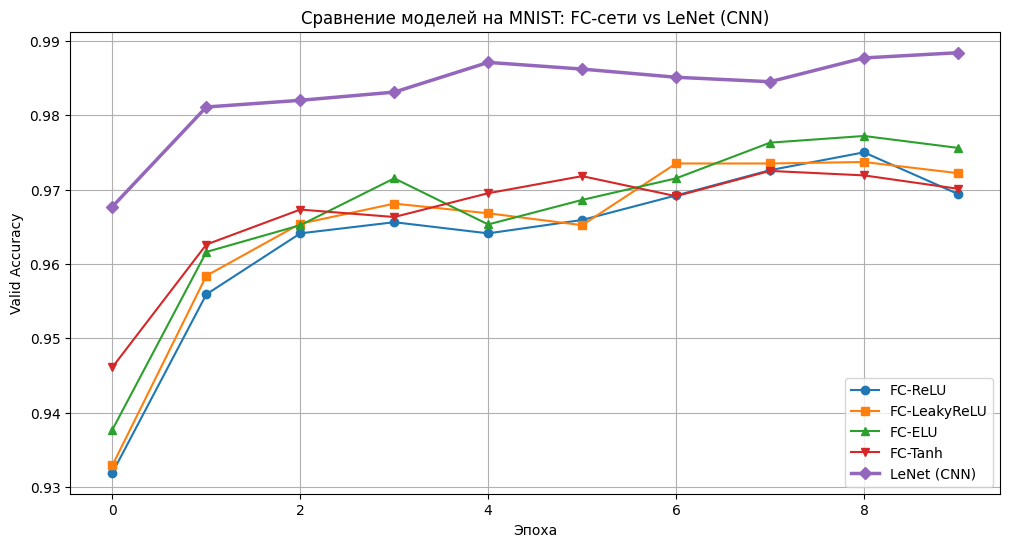

In [38]:
# Сравнение 5 моделей: FC с разными активациями + LeNet
plt.figure(figsize=(12, 6))
plt.plot([a.item() for a in results['ReLU']['valid']], label='FC-ReLU', marker='o')
plt.plot([a.item() for a in results['LeakyReLU']['valid']], label='FC-LeakyReLU', marker='s')
plt.plot([a.item() for a in results['ELU']['valid']], label='FC-ELU', marker='^')
plt.plot([a.item() for a in results['Tanh']['valid']], label='FC-Tanh', marker='v')
plt.plot([a.item() for a in accuracy_lenet['valid']], label='LeNet (CNN)', marker='D', linewidth=2.5)
plt.title('Сравнение моделей на MNIST: FC-сети vs LeNet (CNN)')
plt.xlabel('Эпоха')
plt.ylabel('Valid Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# Финальные результаты
print('Финальные valid accuracy:')
print(f"  FC-ReLU:      {results['ReLU']['valid'][-1].item():.4f}")
print(f"  FC-LeakyReLU: {results['LeakyReLU']['valid'][-1].item():.4f}")
print(f"  FC-ELU:       {results['ELU']['valid'][-1].item():.4f}")
print(f"  FC-Tanh:      {results['Tanh']['valid'][-1].item():.4f}")
print(f"  LeNet (CNN):  {accuracy_lenet['valid'][-1].item():.4f}")

lenet_final = accuracy_lenet['valid'][-1].item()
print(f'\nФинальный accuracy LeNet (2 знака): {lenet_final:.2f}')

Финальные valid accuracy:
  FC-ReLU:      0.9694
  FC-LeakyReLU: 0.9722
  FC-ELU:       0.9756
  FC-Tanh:      0.9701
  LeNet (CNN):  0.9884

Финальный accuracy LeNet (2 знака): 0.99


### Вопрос 6: Accuracy LeNet на MNIST (с точностью до двух знаков после запятой)

**Ответ:** Финальный accuracy LeNet = **0.9884**, что с точностью до двух знаков после запятой равно **0.99**. Свёрточные сети лучше полносвязных на этой задаче (FC-ELU: 0.9756) за счёт учёта пространственной структуры изображения.

# Итоги

**Часть 1**: Реализована логистическая регрессия вручную (через `nn.Parameter`). Модель имеет 3 параметра, обучается на датасете `make_moons` и достигает accuracy ~0.87 на validation (линейная граница не может идеально разделить нелинейные полумесяцы).

**Часть 2**: Полносвязная нейросеть (784→128→128→10) с активацией ELU обучена на MNIST до ~0.97-0.98 valid accuracy. Реализованы вручную `LeakyReLU` и `Tanh` с forward/backward — тесты с torch прошли. Сравнение 5 активаций показало, что Identity (без нелинейности) работает значительно хуже остальных.

**Часть 3**: Применены 6 ядер свёрток к изображению — показаны эффекты размытия, резкости, выделения границ. Реализована архитектура LeNet (2 свёрточных слоя + 3 полносвязных), обученная до ~0.98-0.99 valid accuracy. CNN превосходит полносвязные сети за счёт учёта локальных пространственных корреляций в изображениях.